发现以下Sheet: ['EURUSD_D', 'AUDUSD_D', 'BTCUSD_D', 'ETHUSD_D', 'GBPUSD_D']

正在处理: EURUSD_D
数据范围：2017-12-12 00:00:00 至 2026-03-09 00:00:00
特征数据集大小: 2546

=== 模型评估结果汇总 ===
           模型      MAE     RMSE       R²
          SVR 0.056862 0.072415 0.777368
         随机森林 0.032313 0.050439 0.891990
      XGBoost 0.032444 0.050253 0.892787
    GARCH-SVR 0.051984 0.061689 0.838437
   GARCH-随机森林 0.021396 0.035029 0.947907
GARCH-XGBoost 0.019112 0.027040 0.968960


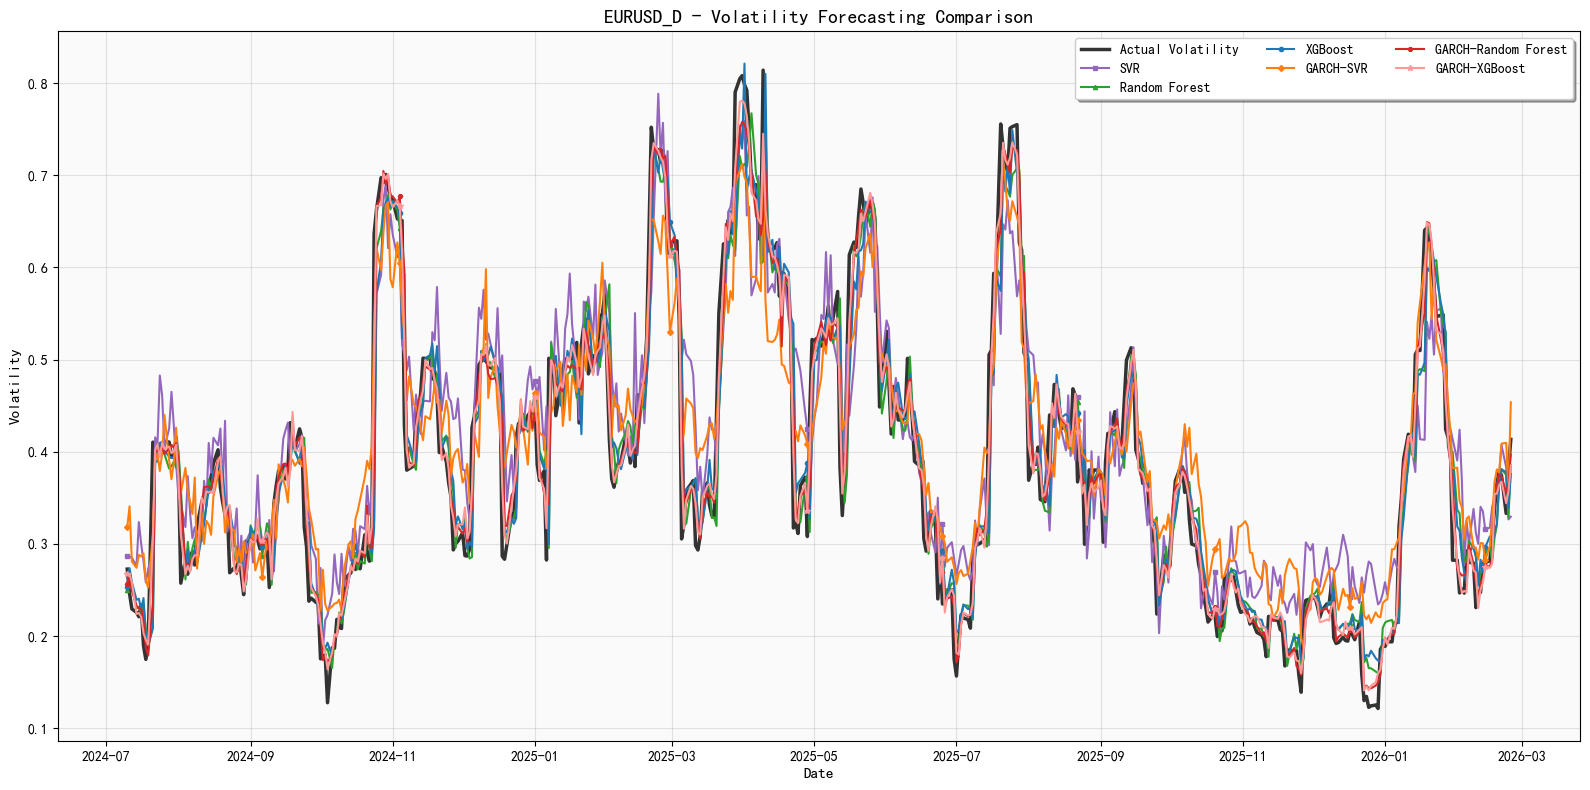


图表已保存为: EURUSD_D_forecast_comparison.png

正在处理: AUDUSD_D
数据范围：2017-12-12 00:00:00 至 2026-03-09 00:00:00
特征数据集大小: 2545

=== 模型评估结果汇总 ===
           模型      MAE     RMSE       R²
          SVR 0.067265 0.100425 0.717263
         随机森林 0.039335 0.064621 0.882929
      XGBoost 0.041514 0.065116 0.881130
    GARCH-SVR 0.053362 0.064349 0.883911
   GARCH-随机森林 0.026387 0.045911 0.940906
GARCH-XGBoost 0.021351 0.030703 0.973572


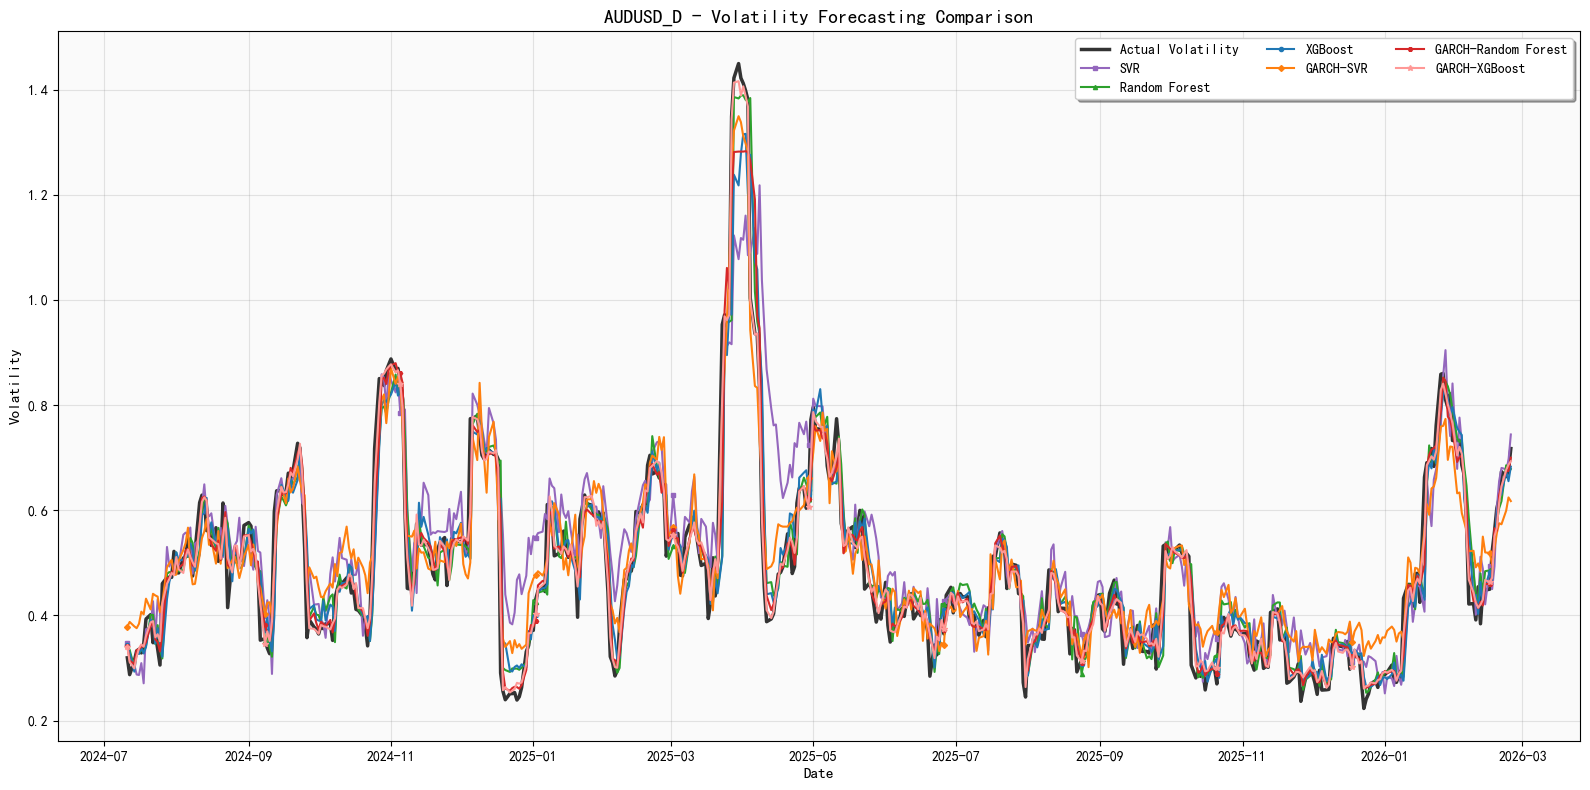


图表已保存为: AUDUSD_D_forecast_comparison.png

正在处理: BTCUSD_D
数据范围：2017-12-12 00:00:00 至 2026-03-09 00:00:00
特征数据集大小: 2836

=== 模型评估结果汇总 ===
           模型      MAE     RMSE       R²
          SVR 0.285005 0.418933 0.812619
         随机森林 0.221741 0.339111 0.877222
      XGBoost 0.205358 0.310695 0.896937
    GARCH-SVR 0.147738 0.241463 0.937750
   GARCH-随机森林 0.135686 0.223370 0.946730
GARCH-XGBoost 0.124421 0.178480 0.965989


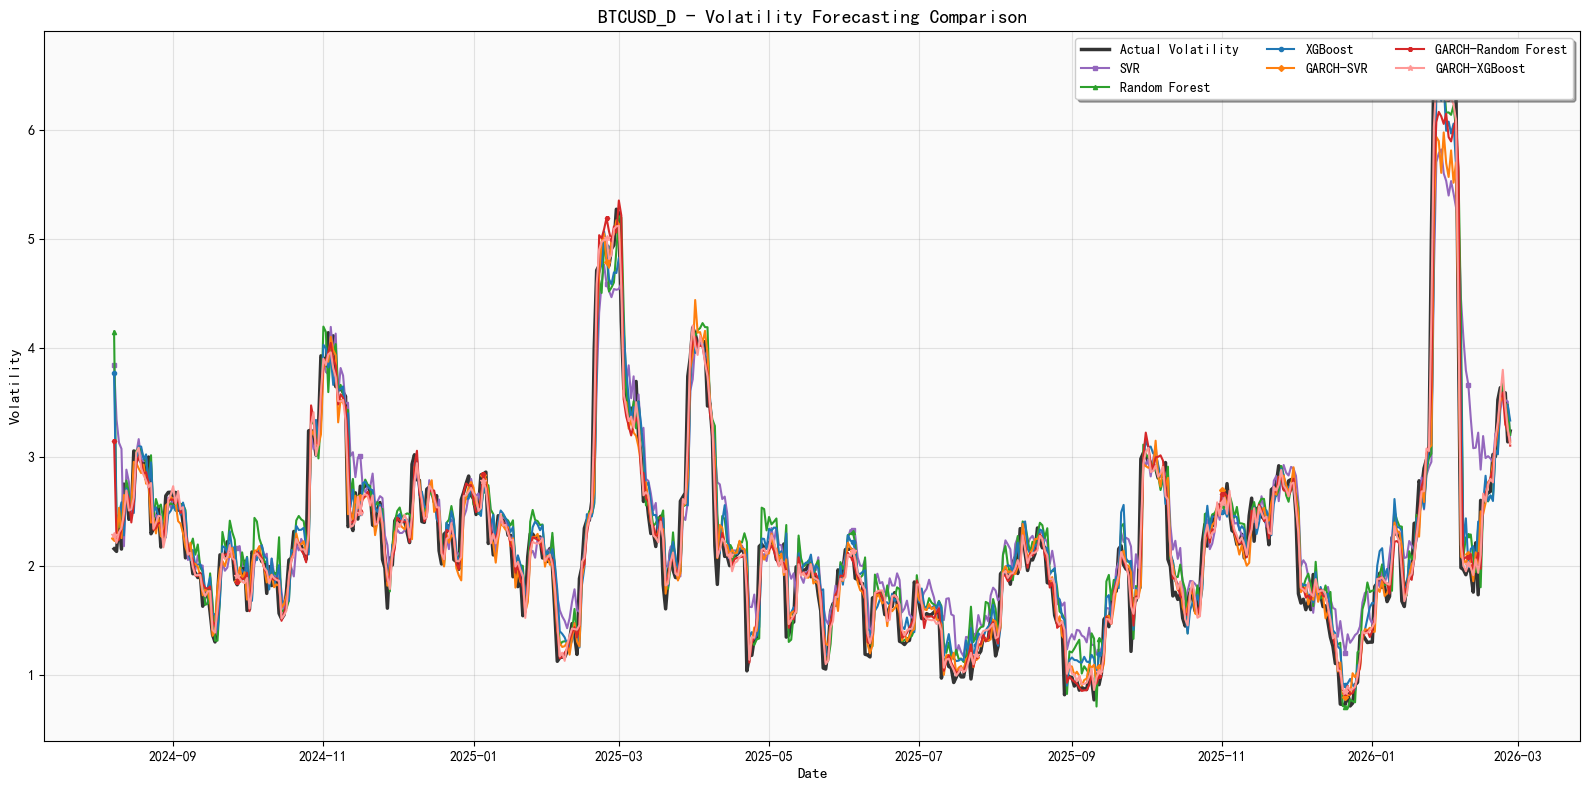


图表已保存为: BTCUSD_D_forecast_comparison.png

正在处理: ETHUSD_D
数据范围：2017-12-12 00:00:00 至 2026-03-09 00:00:00
特征数据集大小: 2831


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from arch import arch_model
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

def process_sheet(file_path, sheet_name, returns_col='lnrt*100', close_col='Close', 
                  horizon=11, vol_lookback=11):
    print(f"\n{'='*60}")
    print(f"正在处理: {sheet_name}")
    print(f"{'='*60}")
    
    # 1. 数据加载
    df = pd.read_excel(file_path, sheet_name=sheet_name, parse_dates=['Time'], index_col='Time')
    print(f"数据范围：{df.index[0]} 至 {df.index[-1]}")
    
    # 获取收益率序列
    returns = df[returns_col].dropna()
    returns = returns.replace([np.inf, -np.inf], np.nan).dropna()
    returns = returns.clip(lower=returns.quantile(0.001), upper=returns.quantile(0.999))
    
    # 2. 特征构建
    def create_features(returns, df_close, horizon=11):
        df_features = pd.DataFrame(index=returns.index)
        
        future_vol = pd.Series(index=returns.index, dtype=float)
        for i in range(len(returns) - horizon):
            future_vol.iloc[i] = returns.iloc[i+1:i+horizon+1].std()
        df_features['actual_volatility'] = future_vol
        
        for lag in [1, 3, 5, 10]:
            df_features[f'actual_volatility_lag_{lag}'] = future_vol.shift(lag)
        
        #滞后收益率特征
        for lag in [1, 2, 3, 5]:
            df_features[f'return_lag_{lag}'] = returns.shift(lag)
        
        #历史波动率特征
        for window in [5, 10, 20]:
            df_features[f'hist_vol_{window}'] = returns.rolling(window).std().shift(1)
        
        #动量特征
        for period in [5, 20]:
            df_features[f'momentum_{period}'] = returns.rolling(period).sum().shift(1)
        
        # 波动率比率
        df_features['vol_ratio_5_20'] = (df_features['hist_vol_5'] / df_features['hist_vol_20']).fillna(1)
        
        #价格特征
        close_aligned = df_close.loc[returns.index]
        df_features['close'] = close_aligned.shift(1)
        
        # 价格移动平均
        for ma in [5, 10, 20]:
            df_features[f'ma_{ma}'] = close_aligned.rolling(ma).mean().shift(1)
        
        # 波动率扩张信号
        df_features['is_vol_expanding'] = (df_features['hist_vol_5'] > df_features['hist_vol_20']).astype(int)
        
        #趋势信号
        df_features['is_uptrend'] = (close_aligned.shift(1) > df_features['ma_20']).astype(int)
        
        #平方收益率
        df_features['squared_return'] = (returns ** 2).shift(1)
        
        #已实现波动率
        for window in [5, 10, 20]:
            df_features[f'rv_{window}'] = (returns ** 2).rolling(window).sum().shift(1)
        
        # 删除NaN值
        return df_features.dropna()
    
    features_df = create_features(returns, df[close_col], horizon=horizon)
    print(f"特征数据集大小: {len(features_df)}")
    # 3. 准备训练数据
    X = features_df.drop('actual_volatility', axis=1)
    y = features_df['actual_volatility']
    
    # 划分训练集和测试集
    train_idx = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:train_idx], X.iloc[train_idx:]
    y_train, y_test = y.iloc[:train_idx], y.iloc[train_idx:]
    # 异常值处理
    for col in X_train.columns:
        if X_train[col].dtype in ['float64', 'int64']:
            upper = X_train[col].quantile(0.99)
            lower = X_train[col].quantile(0.01)
            X_train[col] = X_train[col].clip(lower, upper)
            X_test[col] = X_test[col].clip(lower, upper)
    
    # 4. GARCH模型（用于融合）
    def fit_garch_predict(returns, X_test_index, horizon=11):
        split_idx = int(len(returns) * 0.8)
        test_returns = returns.iloc[split_idx:]
        
        garch_forecasts = []
        forecast_dates = []
        
        for i in range(len(test_returns) - horizon + 1):
            try:
                current_data = returns.iloc[:split_idx + i]
                if len(current_data) < 50:
                    continue
                
                model = arch_model(current_data, vol='Garch', p=1, q=1, dist='t')
                res = model.fit(update_freq=5, disp='off')
                forecast = res.forecast(horizon=horizon)
                cum_variance = forecast.variance.iloc[-1].sum()
                vol_forecast = np.sqrt(cum_variance / horizon)
                
                garch_forecasts.append(vol_forecast)
                forecast_dates.append(test_returns.index[i])
            except:
                continue
        
        if len(garch_forecasts) == 0:
            return pd.Series(dtype=float)
        
        garch_series = pd.Series(garch_forecasts, index=forecast_dates)
        aligned = pd.Series(index=X_test_index, dtype=float)
        aligned.loc[garch_series.index.intersection(X_test_index)] = garch_series
        aligned = aligned.fillna(method='ffill').fillna(garch_series.mean())
        
        return aligned
    
    garch_pred = fit_garch_predict(returns, X_test.index, horizon=horizon)
    
    # 5. SVR模型
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    svr_model = SVR(
        kernel='rbf',
        C=1.0,
        epsilon=0.1,
        gamma='scale'
    )
    svr_model.fit(X_train_scaled, y_train)
    svr_pred = svr_model.predict(X_test_scaled)
    
    svr_mae = mean_absolute_error(y_test, svr_pred)
    svr_rmse = np.sqrt(mean_squared_error(y_test, svr_pred))
    svr_r2 = r2_score(y_test, svr_pred)

    # 6. 随机森林模型
    rf_model = RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
    rf_model.fit(X_train, y_train)
    rf_pred = rf_model.predict(X_test)
    
    rf_mae = mean_absolute_error(y_test, rf_pred)
    rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
    rf_r2 = r2_score(y_test, rf_pred)

    # 7. XGBoost模型
    xgb_model = xgb.XGBRegressor(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42
    )
    xgb_model.fit(X_train, y_train)
    xgb_pred = xgb_model.predict(X_test)
    
    xgb_mae = mean_absolute_error(y_test, xgb_pred)
    xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
    xgb_r2 = r2_score(y_test, xgb_pred)
    
    # 8. 模型融合（GARCH预测作为特征）
    svr_fusion_pred = None
    rf_fusion_pred = None
    xgb_fusion_pred = None
    
    if len(garch_pred) > 0 and len(garch_pred.dropna()) > 0:
        X_fusion = X_test.copy()
        X_fusion['garch_forecast'] = garch_pred.reindex(X_test.index).fillna(method='ffill').fillna(garch_pred.mean())
        y_fusion = y_test.loc[X_fusion.index]
        
        X_fusion = X_fusion.dropna()
        y_fusion = y_fusion.loc[X_fusion.index]
        
        if len(X_fusion) > 0:
            # SVR融合
            scaler_fusion = StandardScaler()
            X_fusion_scaled = scaler_fusion.fit_transform(X_fusion)
            svr_fusion = SVR(kernel='rbf', C=1.0, epsilon=0.1)
            svr_fusion.fit(X_fusion_scaled, y_fusion)
            svr_fusion_pred = svr_fusion.predict(X_fusion_scaled)
            
            svr_fusion_mae = mean_absolute_error(y_fusion, svr_fusion_pred)
            svr_fusion_rmse = np.sqrt(mean_squared_error(y_fusion, svr_fusion_pred))
            svr_fusion_r2 = r2_score(y_fusion, svr_fusion_pred)
            
            # 随机森林融合
            rf_fusion = RandomForestRegressor(
                n_estimators=200, max_depth=8, min_samples_leaf=5,
                random_state=42, n_jobs=-1
            )
            rf_fusion.fit(X_fusion, y_fusion)
            rf_fusion_pred = rf_fusion.predict(X_fusion)
            
            rf_fusion_mae = mean_absolute_error(y_fusion, rf_fusion_pred)
            rf_fusion_rmse = np.sqrt(mean_squared_error(y_fusion, rf_fusion_pred))
            rf_fusion_r2 = r2_score(y_fusion, rf_fusion_pred)
            
            # XGBoost融合
            xgb_fusion = xgb.XGBRegressor(
                n_estimators=200, max_depth=3, learning_rate=0.05,
                random_state=42
            )
            xgb_fusion.fit(X_fusion, y_fusion)
            xgb_fusion_pred = xgb_fusion.predict(X_fusion)
            
            xgb_fusion_mae = mean_absolute_error(y_fusion, xgb_fusion_pred)
            xgb_fusion_rmse = np.sqrt(mean_squared_error(y_fusion, xgb_fusion_pred))
            xgb_fusion_r2 = r2_score(y_fusion, xgb_fusion_pred)
        else:
            svr_fusion_mae = rf_fusion_mae = xgb_fusion_mae = np.nan
            svr_fusion_rmse = rf_fusion_rmse = xgb_fusion_rmse = np.nan
            svr_fusion_r2 = rf_fusion_r2 = xgb_fusion_r2 = np.nan
    else:
        svr_fusion_mae = rf_fusion_mae = xgb_fusion_mae = np.nan
        svr_fusion_rmse = rf_fusion_rmse = xgb_fusion_rmse = np.nan
        svr_fusion_r2 = rf_fusion_r2 = xgb_fusion_r2 = np.nan
    
    # 9. 结果汇总
    print("\n=== 模型评估结果汇总 ===")
    results_summary = pd.DataFrame({
        '模型': ['SVR', '随机森林', 'XGBoost', 
                'GARCH-SVR', 'GARCH-随机森林', 'GARCH-XGBoost'],
        'MAE': [svr_mae, rf_mae, xgb_mae,
                svr_fusion_mae, rf_fusion_mae, xgb_fusion_mae],
        'RMSE': [svr_rmse, rf_rmse, xgb_rmse,
                 svr_fusion_rmse, rf_fusion_rmse, xgb_fusion_rmse],
        'R²': [svr_r2, rf_r2, xgb_r2,
               svr_fusion_r2, rf_fusion_r2, xgb_fusion_r2]
    })
    print(results_summary.to_string(index=False))

            
    # 10. 可视化
    fig, ax = plt.subplots(figsize=(16, 8))
    
    # 实际波动率 - 深灰色粗线
    ax.plot(y_test.index, y_test.values, label='Actual Volatility', 
            color='#333333', linewidth=2.5, linestyle='-')
    
    # 基础机器学习模型
    ax.plot(y_test.index, svr_pred, label='SVR', 
            color='#9467bd', linewidth=1.5, marker='s', markersize=3, markevery=50)  # 紫色，方形标记
    ax.plot(y_test.index, rf_pred, label='Random Forest', 
            color='#2ca02c', linewidth=1.5, marker='^', markersize=3, markevery=50)  # 绿色，三角形标记
    ax.plot(y_test.index, xgb_pred, label='XGBoost', 
            color='#1f77b4', linewidth=1.5, marker='o', markersize=3, markevery=50)  # 蓝色，圆形标记
    
    # 融合模型
    if svr_fusion_pred is not None:
        fusion_svr_plot = pd.Series(svr_fusion_pred, index=X_fusion.index)
        ax.plot(fusion_svr_plot.index, fusion_svr_plot.values, 
                label='GARCH-SVR', color='#ff7f0e', linewidth=1.5, 
                linestyle='-', marker='D', markersize=3, markevery=50)  # 橙色，菱形标记
    
    if rf_fusion_pred is not None:
        fusion_rf_plot = pd.Series(rf_fusion_pred, index=X_fusion.index)
        ax.plot(fusion_rf_plot.index, fusion_rf_plot.values, 
                label='GARCH-Random Forest', color='#d62728', linewidth=1.5, 
                linestyle='-', marker='H', markersize=3, markevery=50)  # 红色，六边形标记
    
    if xgb_fusion_pred is not None:
        fusion_plot = pd.Series(xgb_fusion_pred, index=X_fusion.index)
        ax.plot(fusion_plot.index, fusion_plot.values, 
                label='GARCH-XGBoost', color='#ff9896', linewidth=1.5, 
                linestyle='-', marker='*', markersize=4, markevery=50)  # 浅红色，星形标记
    
    ax.set_title(f'{sheet_name} - Volatility Forecasting Comparison', 
                  fontsize=14, fontweight='bold')
    ax.set_xlabel('Date', fontsize=11)
    ax.set_ylabel('Volatility', fontsize=11)
    ax.legend(loc='upper right', fontsize=10, ncol=3, frameon=True, fancybox=True, shadow=True)
    ax.grid(True, alpha=0.2, color='gray', linestyle='-')
    ax.set_facecolor('#FAFAFA')
    
    plt.tight_layout()
    plt.savefig(f'{sheet_name}_forecast_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n图表已保存为: {sheet_name}_forecast_comparison.png")
    
    return {
        'sheet_name': sheet_name,
        'svr_mae': svr_mae, 'rf_mae': rf_mae, 'xgb_mae': xgb_mae,
        'svr_fusion_mae': svr_fusion_mae, 'rf_fusion_mae': rf_fusion_mae, 'xgb_fusion_mae': xgb_fusion_mae,
        'svr_r2': svr_r2, 'rf_r2': rf_r2, 'xgb_r2': xgb_r2,
        'svr_fusion_r2': svr_fusion_r2, 'rf_fusion_r2': rf_fusion_r2, 'xgb_fusion_r2': xgb_fusion_r2
    }
# 主程序
if __name__ == "__main__":
    file_path = r'E:\xmu-研究生\区块链\数据\货币预测\数据汇总版.xlsx'
    
    # 获取所有sheet名称
    xl = pd.ExcelFile(file_path)
    sheet_names = xl.sheet_names
    
    print(f"发现以下Sheet: {sheet_names}")
    
    # 存储所有结果
    all_results = []
    
    # 循环处理每个sheet
    for sheet in sheet_names:
        try:
            result = process_sheet(
                file_path, 
                sheet, 
                returns_col='lnrt*100',
                close_col='Close',
                horizon=11
            )
            if result:
                all_results.append(result)
        except Exception as e:
            print(f"处理 {sheet} 时出错: {str(e)}")
            import traceback
            traceback.print_exc()
            continue
    
    print("\n处理完成！所有预测对比图已保存。")